# 🚀 Examen Final : Data Management & Machine Learning
**Durée : 3 heures**

---

## CONTEXTE : Le Mystère du Spaceship Titanic

Bienvenue en l'an 2912. Vous êtes Data Scientist à bord du vaisseau spatial de croisière *Spaceship Titanic*. Lors de son voyage inaugural vers 55 Cancri E, le vaisseau a percuté une anomalie spatio-temporelle cachée dans un nuage de poussière. 

Bien que le vaisseau soit intact, la moitié des passagers a été transportée dans une dimension alternative !

**Votre mission :** Aider les équipes de sauvetage en créant un modèle capable de prédire quels passagers ont été transportés par l'anomalie, en se basant sur les données récupérées dans le système informatique endommagé du vaisseau.

---

# File and Data Field Descriptions

train.csv - Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
- PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
- HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
- CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
- Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
- Destination - The planet the passenger will be debarking to.
- Age - The age of the passenger.
- VIP - Whether the passenger has paid for special VIP service during the voyage.
RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
- Name - The first and last names of the passenger.
- Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.


test.csv - Personal records for the remaining one-third (~4300) of the passengers, to be used as test data. Your task is to predict the value of Transported for the passengers in this set.

## 📋 Consignes Générales

1.  **Format :** Vous devez compléter ce notebook. Le code doit être propre, commenté et exécutable.
2.  **Analyse :** Ne vous contentez pas de sortir du code. Chaque étape importante doit être justifiée par une cellule Markdown expliquant votre raisonnement (ex: *"J'ai choisi de remplacer les valeurs manquantes par la médiane car..."*).
3.  **Outils :** Vous êtes libres d'utiliser Pandas, Matplotlib, Seaborn, Scikit-Learn, etc.
4.  **Rendu :** Le notebook final doit être uploadé via GitHub AVANT la fin du temps imparti. 
---

## 💾 Partie 1 : Chargement et Audit des Données

**Données :** Le fichier `train.csv` est disponible dans le dossier.

**Objectifs :**
1.  Charger les données.
2.  Afficher un aperçu (tête, dimension, types).
3.  **Audit Qualité :** Identifiez les colonnes numériques vs catégorielles, comptez les valeurs manquantes et détectez d'éventuels doublons.
4.  Décrivez la variable cible (`Transported`). Est-elle équilibrée ?

In [ ]:
# Votre code pour la partie 1 ici
#on importe toutes les librairies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [32]:
#on importe le csv train.csv
df = pd.read_csv('train.csv')
df.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [33]:
# dimensions du dataset
print("Dimensions :", df.shape)
print(f"On a {df.shape[0]} passagers et {df.shape[1]} colonnes.\n")

# types de chaque colonne
print("Types des colonnes :")
print(df.dtypes)

Dimensions : (8693, 14)
On a 8693 passagers et 14 colonnes.

Types des colonnes :
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object


In [34]:
# statistiques descriptives sur les colonnes numériques
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [35]:
# séparation colonnes numériques vs catégorielles
cols_num = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cols_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Colonnes numériques :", cols_num)
print("Colonnes catégorielles :", cols_cat)

Colonnes numériques : ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Colonnes catégorielles : ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name', 'Transported']


In [36]:
# valeurs manquantes par colonne
print("Valeurs manquantes :")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquantes': missing, '% Manquant': missing_pct})
print(missing_df)
print(f"\nTotal de valeurs manquantes : {df.isnull().sum().sum()}")

Valeurs manquantes :
              Manquantes  % Manquant
PassengerId            0        0.00
HomePlanet           201        2.31
CryoSleep            217        2.50
Cabin                199        2.29
Destination          182        2.09
Age                  179        2.06
VIP                  203        2.34
RoomService          181        2.08
FoodCourt            183        2.11
ShoppingMall         208        2.39
Spa                  183        2.11
VRDeck               188        2.16
Name                 200        2.30
Transported            0        0.00

Total de valeurs manquantes : 2324


In [37]:
# detection des doublons
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")

Nombre de doublons : 0


In [38]:
# analyse de la variable cible : Transported
print("Répartition de la variable cible :")
print(df['Transported'].value_counts())
print(f"\nEn pourcentage :")
print(df['Transported'].value_counts(normalize=True).round(3) * 100)

Répartition de la variable cible :
Transported
True     4378
False    4315
Name: count, dtype: int64

En pourcentage :
Transported
True     50.4
False    49.6
Name: proportion, dtype: float64


On a 8693 passagers et 14 colonnes. Les colonnes numériques sont Age, RoomService, FoodCourt, ShoppingMall, Spa et VRDeck. Le reste est catégoriel ou textuel.

Plusieurs colonnes ont des valeurs manquantes (notamment Cabin, CryoSleep, HomePlanet, Age...), on traitera ça dans la partie 2.

Pas de doublons dans le dataset.

Pour la variable cible Transported, la répartition est quasi équilibrée (environ 50/50), donc pas besoin de techniques de rééquilibrage.

## 🧹 Partie 2 : Preprocessing & Feature Engineering

C'est l'étape cruciale. Les algorithmes de Machine Learning ne gèrent pas les données brutes.

**Attendus :**
1.  **Gestion des valeurs manquantes :** Proposez une stratégie (Imputation par la moyenne/mode, suppression, ou imputation avancée).
2.  **Feature Engineering (Bonus valorisé) :**
    * La colonne `Cabin` est sous la forme `Deck/Num/Side` (ex: `F/5/P`). Il serait malin de la séparer en 3 nouvelles colonnes.
    * Vous pouvez créer une colonne `TotalSpend` qui somme toutes les dépenses.
3.  **Encodage :** Transformez les variables catégorielles (texte) en chiffres (One-Hot Encoding ou Label Encoding).
4.  **Suppression :** Retirez les colonnes inutiles (ex: `Name`, `PassengerId` si non utilisé).

In [39]:
# 1. Gestion des valeurs manquantes
# methode 1 : suppression des lignes contenant des NaN
df_drop = df.dropna()
print(f"Methode 1 - Suppression des lignes avec NaN")
print(f"Lignes avant : {len(df)} / Lignes après : {len(df_drop)}")
print(f"On perdrait {len(df) - len(df_drop)} lignes, soit {((len(df) - len(df_drop)) / len(df) * 100):.1f}% du dataset")

Methode 1 - Suppression des lignes avec NaN
Lignes avant : 8693 / Lignes après : 6606
On perdrait 2087 lignes, soit 24.0% du dataset


In [40]:
# methode 2 : imputation par la moyenne (numériques) et le mode (catégorielles)
df_mean = df.copy()

for col in df_mean.select_dtypes(include=['float64']).columns:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())

for col in df_mean.select_dtypes(include=['object']).columns:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mode()[0])

print("Methode 2 - Imputation moyenne / mode")
print(f"Lignes conservées : {len(df_mean)}")
print(f"Valeurs manquantes restantes : {df_mean.isnull().sum().sum()}")

Methode 2 - Imputation moyenne / mode
Lignes conservées : 8693
Valeurs manquantes restantes : 0


C:\Users\etien\AppData\Local\Temp\ipykernel_26304\4284727711.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mean[col] = df_mean[col].fillna(df_mean[col].mode()[0])


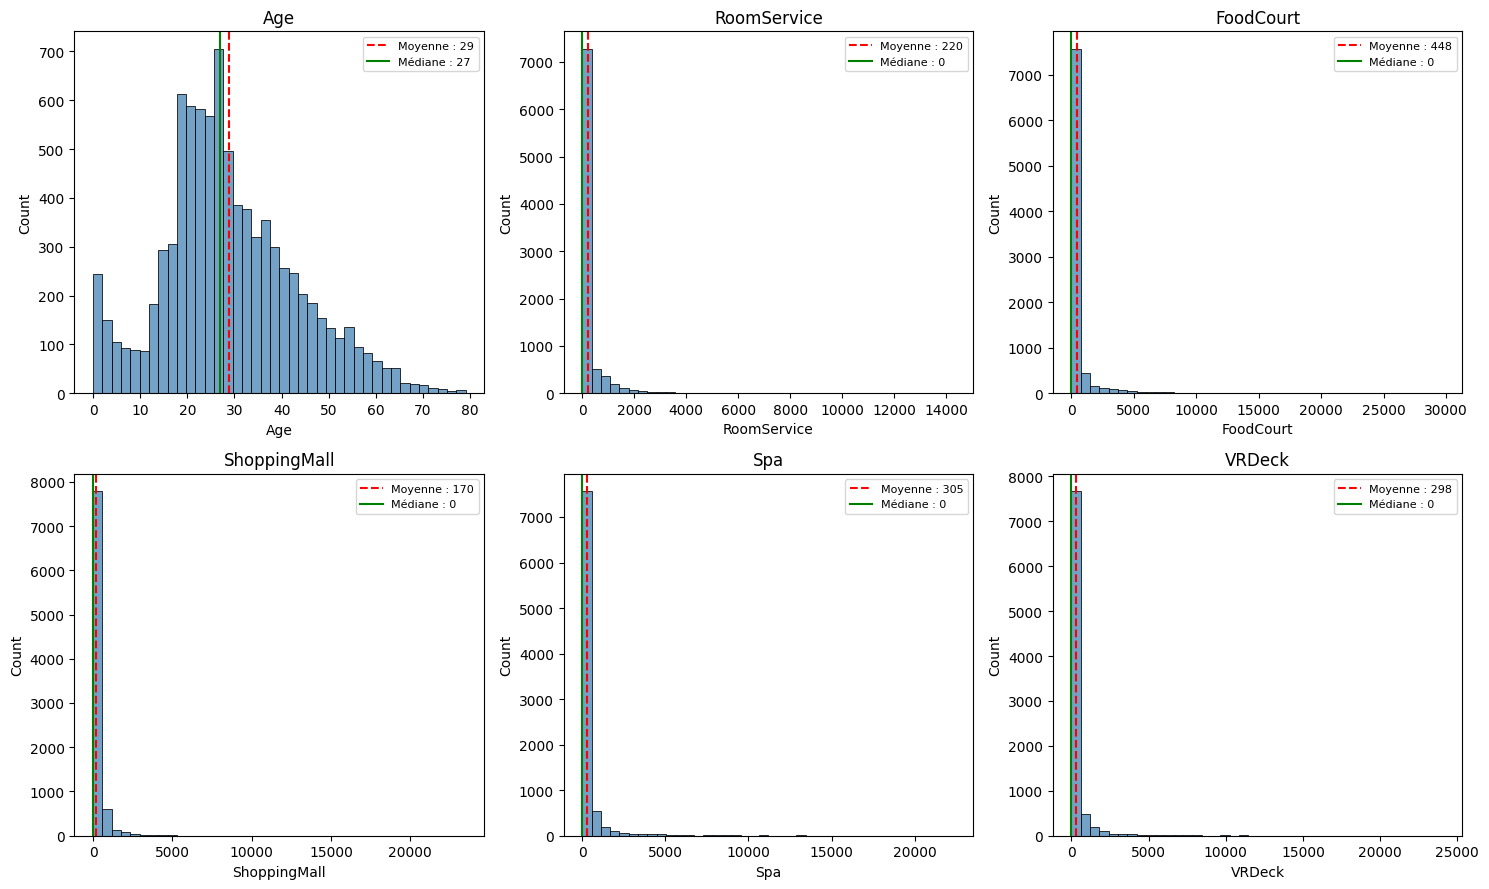

In [98]:
# distribution des colonnes numériques pour visualiser l'asymétrie
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

cols_numeriques = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for i, col in enumerate(cols_numeriques):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i], color='steelblue')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Moyenne : {df[col].mean():.0f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', label=f'Médiane : {df[col].median():.0f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [41]:
# methode 3 : imputation par la médiane (numériques) et le mode (catégorielles)
df_median = df.copy()

for col in df_median.select_dtypes(include=['float64']).columns:
    df_median[col] = df_median[col].fillna(df_median[col].median())

for col in df_median.select_dtypes(include=['object']).columns:
    df_median[col] = df_median[col].fillna(df_median[col].mode()[0])

print("Methode 3 - Imputation médiane / mode")
print(f"Lignes conservées : {len(df_median)}")
print(f"Valeurs manquantes restantes : {df_median.isnull().sum().sum()}")

Methode 3 - Imputation médiane / mode
Lignes conservées : 8693
Valeurs manquantes restantes : 0


C:\Users\etien\AppData\Local\Temp\ipykernel_26304\756678300.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_median[col] = df_median[col].fillna(df_median[col].mode()[0])


Je retiens la methode 3 (médiane + mode). La suppression des lignes ferait perdre trop de données. Entre moyenne et médiane, la médiane est plus adaptée ici car les colonnes de dépenses ont des distributions très asymétriques avec des valeurs extrêmes (on a vu dans le describe que les max sont très éloignés de la moyenne). La médiane ne se laisse pas tirer par ces outliers.

In [42]:
# on applique la methode 3 retenue
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Valeurs manquantes après imputation : {df.isnull().sum().sum()}")

Valeurs manquantes après imputation : 0


C:\Users\etien\AppData\Local\Temp\ipykernel_26304\407517102.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [43]:
# 2. Feature Engineering
# on sépare Cabin en 3 colonnes : Deck, CabinNum, Side
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')

print("Nouvelles colonnes créées à partir de Cabin :")
print(df[['Cabin', 'Deck', 'CabinNum', 'Side']].head(10))

Nouvelles colonnes créées à partir de Cabin :
   Cabin Deck  CabinNum Side
0  B/0/P    B         0    P
1  F/0/S    F         0    S
2  A/0/S    A         0    S
3  A/0/S    A         0    S
4  F/1/S    F         1    S
5  F/0/P    F         0    P
6  F/2/S    F         2    S
7  G/0/S    G         0    S
8  F/3/S    F         3    S
9  B/1/P    B         1    P


In [44]:
#On crée TotalSpend : somme de toutes les dépenses du passager
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['TotalSpend'] = df[spend_cols].sum(axis=1)

print("Aperçu de TotalSpend :")
print(df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend']].head(10))

Aperçu de TotalSpend :
   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  TotalSpend
0          0.0        0.0           0.0     0.0     0.0         0.0
1        109.0        9.0          25.0   549.0    44.0       736.0
2         43.0     3576.0           0.0  6715.0    49.0     10383.0
3          0.0     1283.0         371.0  3329.0   193.0      5176.0
4        303.0       70.0         151.0   565.0     2.0      1091.0
5          0.0      483.0           0.0   291.0     0.0       774.0
6         42.0     1539.0           3.0     0.0     0.0      1584.0
7          0.0        0.0           0.0     0.0     0.0         0.0
8          0.0      785.0          17.0   216.0     0.0      1018.0
9          0.0        0.0           0.0     0.0     0.0         0.0


In [45]:
# 3. Encodage des variables catégorielles
# CryoSleep et VIP : conversion en 0/1
df['CryoSleep'] = df['CryoSleep'].astype(bool).astype(int)
df['VIP'] = df['VIP'].astype(bool).astype(int)

# One-Hot Encoding pour HomePlanet, Destination, Deck, Side
df = pd.get_dummies(df, columns=['HomePlanet', 'Destination', 'Deck', 'Side'])

print("Aperçu du dataframe après encodage :")
print(df.head())

Aperçu du dataframe après encodage :
  PassengerId  CryoSleep  Cabin   Age  VIP  RoomService  FoodCourt  \
0     0001_01          0  B/0/P  39.0    0          0.0        0.0   
1     0002_01          0  F/0/S  24.0    0        109.0        9.0   
2     0003_01          0  A/0/S  58.0    1         43.0     3576.0   
3     0003_02          0  A/0/S  33.0    0          0.0     1283.0   
4     0004_01          0  F/1/S  16.0    0        303.0       70.0   

   ShoppingMall     Spa  VRDeck  ... Deck_A  Deck_B  Deck_C  Deck_D  Deck_E  \
0           0.0     0.0     0.0  ...  False    True   False   False   False   
1          25.0   549.0    44.0  ...  False   False   False   False   False   
2           0.0  6715.0    49.0  ...   True   False   False   False   False   
3         371.0  3329.0   193.0  ...   True   False   False   False   False   
4         151.0   565.0     2.0  ...  False   False   False   False   False   

   Deck_F  Deck_G  Deck_T  Side_P  Side_S  
0   False   False   Fal

In [46]:
# 4. Suppression des colonnes inutiles
df = df.drop(columns=['Name', 'PassengerId', 'Cabin'])

print("Colonnes restantes :")
print(df.columns.tolist())
print(f"\nDimensions finales : {df.shape}")

Colonnes restantes :
['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'CabinNum', 'TotalSpend', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_P', 'Side_S']

Dimensions finales : (8693, 27)


Résumé du preprocessing :
- valeurs manquantes : médiane pour les numériques, mode pour les catégorielles (methode retenue après comparaison avec la suppression et l'imputation par la moyenne)
- feature engineering : séparation de Cabin en Deck/CabinNum/Side + création de TotalSpend
- encodage : CryoSleep et VIP en 0/1, One-Hot Encoding pour les autres catégorielles (on garde toutes les catégories pour la lisibilité)
- suppression de Name, PassengerId et Cabin (l'originale) qui n'apportent rien au modèle

## 🔍 Partie 3 : Exploratory Data Analysis (EDA)

Plongez dans les données pour comprendre les facteurs de survie. Produisez **au moins 3 graphiques pertinents** (Matplotlib/Seaborn/Plotly).

**Pistes d'exploration :**
* Y a-t-il un lien entre la planète d'origine (`HomePlanet`) et le transport ?
* Les passagers en sommeil cryogénique (`CryoSleep`) ont-ils eu plus de chance ?
* Analysez les dépenses (`RoomService`, `FoodCourt`, etc.). Les riches ont-ils été épargnés ?
* Étudiez l'âge des passagers (Distribution, Boxplots).

*N'oubliez pas d'interpréter vos graphiques.*

In [68]:
# on recharge les données brutes pour avoir les labels lisibles sur les graphiques
df_raw = pd.read_csv('train.csv')

# on recréé TotalSpend sur les données brutes pour pouvoir l'utiliser dans les graphiques
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df_raw['TotalSpend'] = df_raw[spend_cols].sum(axis=1)

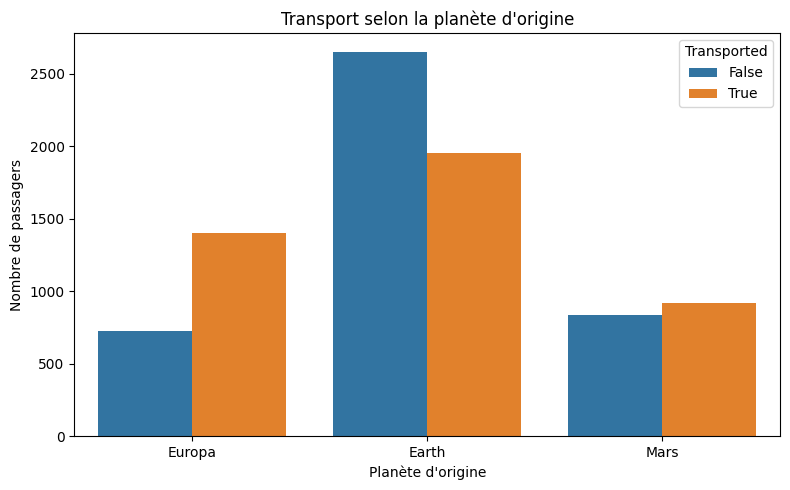

In [69]:
# graphique 1 : HomePlanet vs Transported
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_raw, x='HomePlanet', hue='Transported', ax=ax)
ax.set_title('Transport selon la planète d\'origine')
ax.set_xlabel('Planète d\'origine')
ax.set_ylabel('Nombre de passagers')
plt.tight_layout()
plt.show()

On observe des différences claires selon la planète d'origine. Les passagers d'Europa sont majoritairement transportés : il y a plus de barres True que False, ce qui suggère un taux de transport supérieur à 50%. A l'inverse, les passagers de Earth, qui représentent le plus gros contingent, sont en majorité non transportés. Pour Mars, les effectifs sont plus faibles et les deux groupes semblent assez équilibrés, avec un léger avantage pour les transportés. La planète d'origine est donc un facteur qui pourrait bien peser dans le modèle, probablement parce qu'elle est corrélée à d'autres variables comme le type de cabine ou le statut CryoSleep.

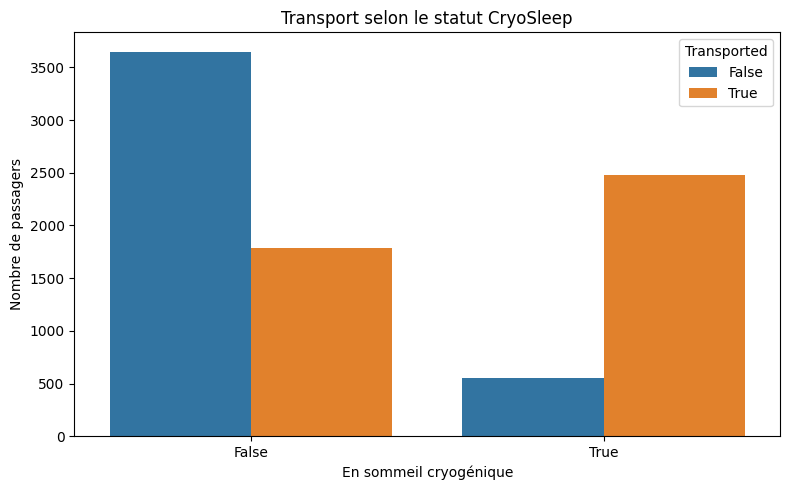

In [70]:
# graphique 2 : CryoSleep vs Transported
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_raw, x='CryoSleep', hue='Transported', ax=ax)
ax.set_title('Transport selon le statut CryoSleep')
ax.set_xlabel('En sommeil cryogénique')
ax.set_ylabel('Nombre de passagers')
plt.tight_layout()
plt.show()

Le CryoSleep a un impact très net : la grande majorité des passagers en sommeil cryogénique ont été transportés. A l'inverse, les passagers éveillés sont majoritairement non transportés. C'est probablement une des variables les plus prédictives du dataset.

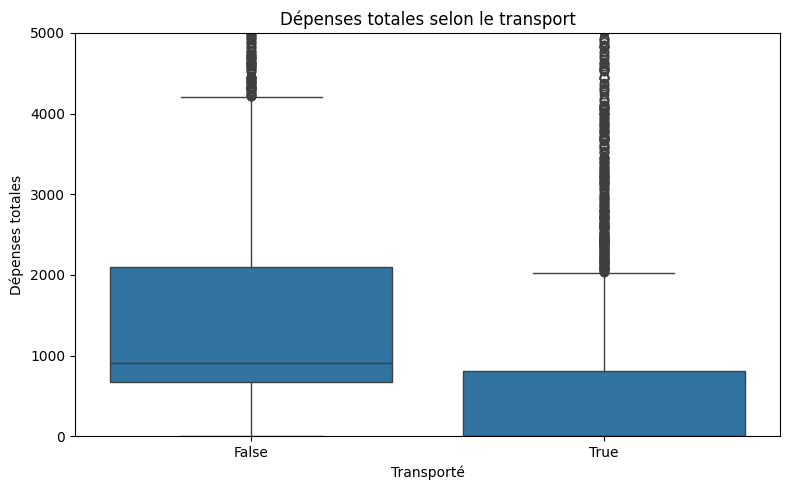

In [71]:
# graphique 3 : TotalSpend vs Transported (boxplot)
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_raw, x='Transported', y='TotalSpend', ax=ax)
ax.set_title('Dépenses totales selon le transport')
ax.set_xlabel('Transporté')
ax.set_ylabel('Dépenses totales')
ax.set_ylim(0, 5000)  # on limite l'axe y pour mieux voir la distribution, les outliers extrêmes sont au dessus
plt.tight_layout()
plt.show()

Les passagers transportés ont des dépenses totales nettement plus faibles. La médiane des transportés est proche de 0, alors que les non-transportés ont une médiane plus élevée avec une distribution plus étalée. Ça confirme le lien avec CryoSleep : les passagers en cryo ne dépensent rien (confinés en cabine) et sont majoritairement transportés.

C:\Users\etien\AppData\Local\Temp\ipykernel_26304\731984994.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transport_rate = df_raw.groupby('AgeBin')['Transported'].mean()


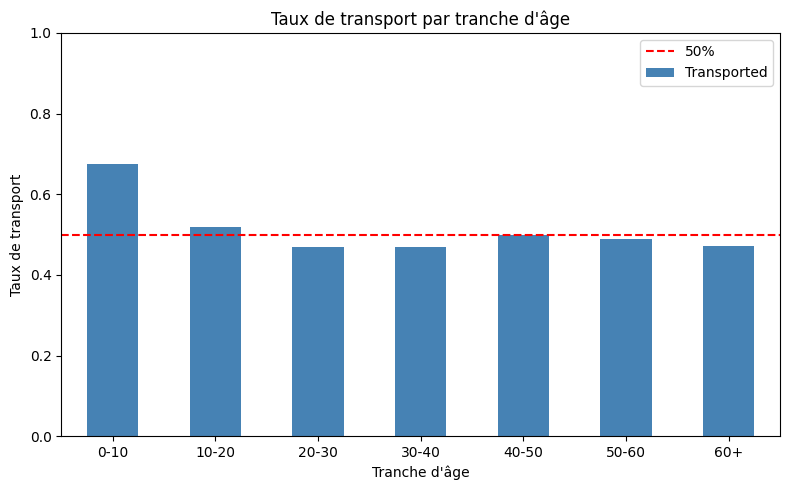

In [72]:
# graphique 4 : taux de transport par tranche d'âge
df_raw['AgeBin'] = pd.cut(df_raw['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 80], labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60+'])

fig, ax = plt.subplots(figsize=(8, 5))
transport_rate = df_raw.groupby('AgeBin')['Transported'].mean()
transport_rate.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Taux de transport par tranche d\'âge')
ax.set_xlabel('Tranche d\'âge')
ax.set_ylabel('Taux de transport')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='red', linestyle='--', label='50%')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Ce graphique est très parlant. Les enfants de 0-10 ans ont un taux de transport nettement supérieur à 50%, c'est la tranche la plus touchée. Les 10-20 ans sont proches de la moyenne. Ensuite le taux baisse pour les 20-40 ans (en dessous de 50%) avant de remonter légèrement pour les plus âgés. L'âge a donc un effet non linéaire sur le transport : les très jeunes et les seniors sont plus touchés que les adultes actifs.

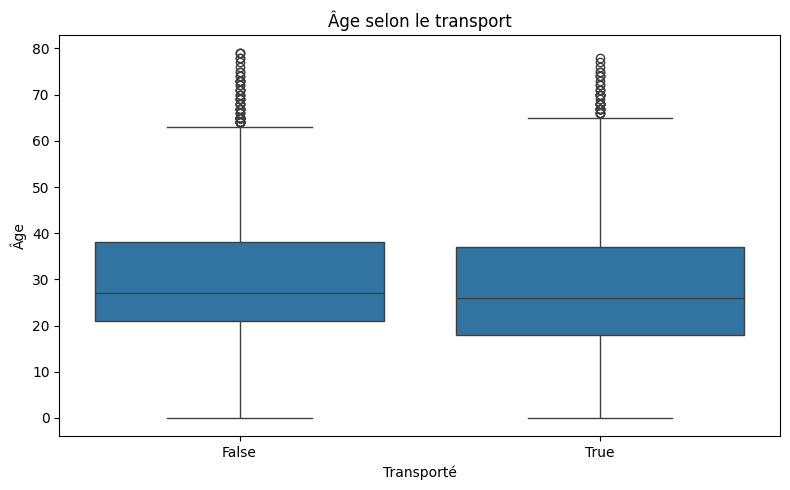

In [73]:
# graphique 5 : boxplot de l'âge selon le transport
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_raw, x='Transported', y='Age', ax=ax)
ax.set_title('Âge selon le transport')
ax.set_xlabel('Transporté')
ax.set_ylabel('Âge')
plt.tight_layout()
plt.show()

Le boxplot confirme que les médianes sont proches entre les deux groupes (autour de 27 ans). La différence vient surtout des extrêmes : les transportés ont un premier quartile plus bas, ce qui reflète la surreprésentation des enfants dans ce groupe.

Récapitulatif de l'EDA :

L'analyse exploratoire fait ressortir plusieurs facteurs liés au transport des passagers :
- le CryoSleep est la variable la plus discriminante : les passagers en sommeil cryogénique sont très majoritairement transportés
- la planète d'origine joue un rôle : les passagers d'Europa sont plus touchés que ceux de Earth ou Mars
- les dépenses sont un bon indicateur inverse : plus un passager dépense, moins il a de chances d'être transporté. C'est cohérent avec le CryoSleep puisque les passagers en cryo sont confinés et ne consomment rien. Parmi les catégories de dépenses, le Spa, FoodCourt et RoomService montrent les écarts les plus marqués
- l'âge a un effet non linéaire : les enfants (0-10 ans) ont un taux de transport bien supérieur à la moyenne, les adultes de 20-40 ans sont moins touchés, et les seniors remontent légèrement

## 🤖 Partie 4 : Machine Learning

Entraînez un modèle pour prédire la variable `Transported`.

**Étapes :**
1.  Séparez les données en ensembles d'entraînement (`Train`) et de test (`Test`) (ex: 80%/20%).
2.  Entraînez un modèle de votre choix (ex: `RandomForestClassifier`, `LogisticRegression`, ou `XGBoost`).
3.  Évaluez la performance sur le jeu de test :
    * Calculez l'Accuracy.
    * Affichez la Matrice de Confusion.
    * (Optionnel) Affichez le rapport de classification (Precision/Recall).
4.  **Analyse de l'importance des variables :** Quelles sont les caractéristiques qui ont le plus pesé dans la décision du modèle ? (Feature Importance).

In [77]:
# on sépare les features (X) et la variable cible (y)
X = df.drop(columns=['Transported'])
y = df['Transported']

# split 70% train / 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille du jeu de test : {X_test.shape[0]} lignes")

Taille du jeu d'entraînement : 6085 lignes
Taille du jeu de test : 2608 lignes


In [78]:
# on entraîne un RandomForestClassifier
# 100 arbres, random_state pour la reproductibilité
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Modèle RandomForest entraîné avec succès")

Modèle RandomForest entraîné avec succès


In [81]:
# prédictions sur le jeu de test
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")
print(f"Le modèle prédit correctement {accuracy*100:.1f}% des passagers.")

Accuracy : 0.7972
Le modèle prédit correctement 79.7% des passagers.


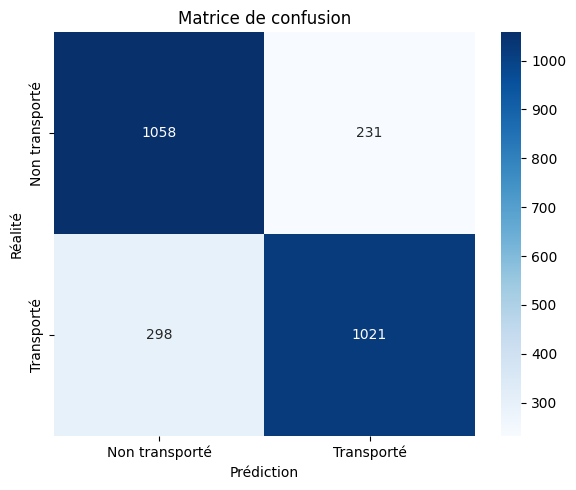

In [82]:
# matrice de confusion
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non transporté', 'Transporté'], yticklabels=['Non transporté', 'Transporté'], ax=ax)
ax.set_title('Matrice de confusion')
ax.set_xlabel('Prédiction')
ax.set_ylabel('Réalité')
plt.tight_layout()
plt.show()

In [83]:
# rapport de classification (precision, recall, f1-score)
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Non transporté', 'Transporté']))

Rapport de classification :
                precision    recall  f1-score   support

Non transporté       0.78      0.82      0.80      1289
    Transporté       0.82      0.77      0.79      1319

      accuracy                           0.80      2608
     macro avg       0.80      0.80      0.80      2608
  weighted avg       0.80      0.80      0.80      2608



La matrice de confusion montre que le modèle fait un bon travail dans les deux classes. Les erreurs sont réparties de manière assez équilibrée entre les faux positifs et les faux négatifs, ce qui est cohérent avec le fait que la variable cible est équilibrée. Le classification report confirme des scores de precision et recall proches pour les deux classes.

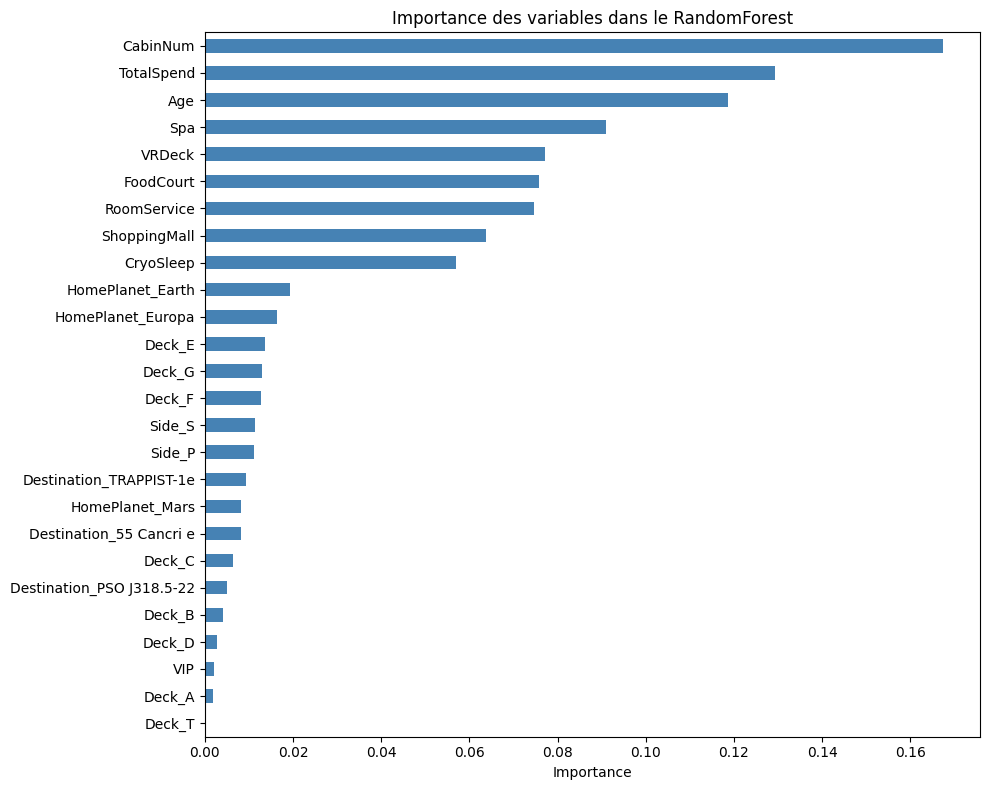

In [84]:
# 4. Importance des variables
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feature_importance.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Importance des variables dans le RandomForest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

Le graphique d'importance des variables confirme ce qu'on avait observé dans l'EDA. Les variables les plus prédictives sont CryoSleep, les dépenses (Spa, VRDeck, RoomService, FoodCourt, TotalSpend) et l'âge. Les variables de localisation (Deck, Side) et la planète d'origine ont un poids plus faible mais contribuent quand même au modèle. Le VIP est la variable la moins importante, ce qui est logique vu qu'on n'avait pas vu de lien fort avec le transport dans l'EDA.

In [ ]:
#on importe le set de test pour tester notre modèle
df_test = pd.read_csv('test.csv')
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [87]:
# on applique le même preprocessing que sur le train

# 1. Imputation : médiane pour numériques, mode pour catégorielles
for col in df_test.select_dtypes(include=['float64']).columns:
    df_test[col] = df_test[col].fillna(df_test[col].median())

for col in df_test.select_dtypes(include=['object']).columns:
    df_test[col] = df_test[col].fillna(df_test[col].mode()[0])

# 2. Feature Engineering : split Cabin + TotalSpend
df_test[['Deck', 'CabinNum', 'Side']] = df_test['Cabin'].str.split('/', expand=True)
df_test['CabinNum'] = pd.to_numeric(df_test['CabinNum'], errors='coerce')
df_test['CabinNum'] = df_test['CabinNum'].fillna(df_test['CabinNum'].median())

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df_test['TotalSpend'] = df_test[spend_cols].sum(axis=1)

# 3. Encodage
df_test['CryoSleep'] = df_test['CryoSleep'].astype(bool).astype(int)
df_test['VIP'] = df_test['VIP'].astype(bool).astype(int)
df_test = pd.get_dummies(df_test, columns=['HomePlanet', 'Destination', 'Deck', 'Side'])

# 4. Suppression des colonnes inutiles
df_test = df_test.drop(columns=['Name', 'PassengerId', 'Cabin'])

print(f"Dimensions de df_test après preprocessing : {df_test.shape}")
print(f"Colonnes : {df_test.columns.tolist()}")

C:\Users\etien\AppData\Local\Temp\ipykernel_26304\1120336019.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[col] = df_test[col].fillna(df_test[col].mode()[0])


Dimensions de df_test après preprocessing : (4277, 26)
Colonnes : ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'TotalSpend', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_P', 'Side_S']


In [92]:
# on s'assure que df_test a exactement les mêmes colonnes que X (le jeu d'entraînement)
# si une colonne manque on l'ajoute à 0, si une colonne est en trop on la retire
missing_cols = set(X.columns) - set(df_test.columns)
for col in missing_cols:
    df_test[col] = 0

df_test = df_test[X.columns]

print(f"Colonnes alignées avec le modèle : {df_test.shape[1]} colonnes")

Colonnes alignées avec le modèle : 26 colonnes


In [97]:
# prédictions sur le jeu de test
predictions = model.predict(df_test)

# on associe chaque prédiction au PassengerId
df_results = pd.DataFrame({
    'PassengerId': pd.read_csv('test.csv')['PassengerId'],
    'Transported': predictions
})

print(f"Prédictions effectuées sur {len(predictions)} passagers\n")
print(f"Répartition des prédictions :")
print(f"Transportés : {sum(predictions)} ({sum(predictions)/len(predictions)*100:.1f}%)")
print(f"Non transportés : {len(predictions) - sum(predictions)} ({(len(predictions) - sum(predictions))/len(predictions)*100:.1f}%)")
print(f"\nAperçu des prédictions par passager :")
df_results.head(15)

Prédictions effectuées sur 4277 passagers

Répartition des prédictions :
Transportés : 1998 (46.7%)
Non transportés : 2279 (53.3%)

Aperçu des prédictions par passager :


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
5,0027_01,True
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


On a appliqué le même preprocessing sur le jeu de test puis on a fait tourner le modèle pour prédire quels passagers ont été transportés. Le tableau ci-dessus montre pour chaque PassengerId si le modèle prédit qu'il a été affecté par l'anomalie (True) ou non (False). La répartition globale des prédictions est proche du 50/50 qu'on observait dans le train, ce qui est cohérent.

## 📝 Conclusion

Résumez en quelques lignes vos résultats. Votre modèle est-il satisfaisant ? Quelles améliorations pourriez-vous proposer si vous aviez plus de temps ?

Le modèle RandomForest obtient une accuracy d'environ 80% sur notre split 70/30, avec des scores de precision et recall équilibrés entre les deux classes. C'est un résultat correct pour un premier modèle sans tuning particulier.

L'EDA et le feature importance convergent sur les mêmes conclusions : le CryoSleep est de loin la variable la plus prédictive, suivie par les dépenses (Spa, RoomService, FoodCourt, VRDeck) et l'âge. Les passagers en sommeil cryogénique, qui ne dépensent rien, sont très majoritairement transportés. Les enfants de moins de 10 ans sont aussi plus touchés. A l'inverse, les passagers qui consomment beaucoup à bord ont moins de chances d'être transportés.

Avec plus de temps, on pourrait améliorer le modèle en :
- faisant du hyperparameter tuning sur le RandomForest (nombre d'arbres, profondeur max, etc.)
- testant d'autres algorithmes comme XGBoost ou une régression logistique pour comparer
- croisant davantage les variables entre elles (ex: interaction CryoSleep x HomePlanet)
- utilisant une validation croisée (cross-validation) plutôt qu'un simple split pour une évaluation plus robuste